In [1]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np
import pandas as pd
import re
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.cm as cm
from matplotlib.lines import Line2D  # Import Line2D for custom legend

In [2]:
data = "BF_CPP_DATA.csv"
data_df = pd.read_csv(data)
loc_ids=data_df.iloc[:,0]

In [3]:
def read_and_process_file(file_path):
    result_list = []

    try:
        with open(file_path, 'r') as file:
            lines = file.readlines()

            # Extract every second line
            for i in range(1, len(lines), 2):
                line = lines[i].strip()

                # Split the line into a list of integers
                integer_series = list(map(int, line.split()))

                result_list.append(integer_series)

        return result_list

    except FileNotFoundError:
        print("File not found. Please check the file path.")
        return None
    except Exception as e:
        print("An error occurred:", e)
        return None

def create_csv_from_2d_list(values, loc_ids, file_name="brownfields_top20_output.csv"):
    # Sum each column of the 2D list
    column_sums = [sum(col) for col in zip(*values)]
    # Create a DataFrame with indices and summed column values
    df = pd.DataFrame({
        'loc_ids': loc_ids,
        'obs_values': column_sums})
    df_sorted = df.sort_values(by=df.columns[1], ascending=False)
    # Save the DataFrame to a CSV file in the same directory
    df_sorted.to_csv(file_name, index=False)

def normalize_history(history):
    for line in history:
        sum=0
        for element in line:
            sum=sum+element[1]
        for element in line:
            element[1]=element[1]/sum

def get_history_indices_list(history):
    index_list=[]
    for line in history:
        for element in line:
            if element[0] not in index_list:
                index_list.append(element[0])
    return index_list

def normalize_read_list(list):
    line_counter=0
    for line in list:
        sum=0
        for element in line:
            sum=sum+element
        element_counter=0
        for element in line:
            list[line_counter][element_counter]=element/sum
            element_counter+=1
        line_counter+=1

In [4]:
master_distrib=[0]*16057 # num locs + 1, CAREFUL, this list starts from index 1 TO PLOT the right location indices. The exported location indices also start from 1. 
# The data for brownfield indices start from 0. After exporting the best indices, subtract 1 from them while accessing to brownfield data. 
master_top_10=[[0,0] for i in range(22)]
file_name="recorder.txt"
read_list=read_and_process_file(file_name)
history=[]

# Get the resulting list, normalize it inside each combination length, sum them for each location and get the indices of top n observation rates.
normalize_read_list(read_list)
np_read_list=np.array(read_list)
column_sums = np.sum(np_read_list, axis=0)
indexed_column_sums=[]
for i in range(len(column_sums)):
    indexed_column_sums.append([column_sums[i],i])
np_indexed_column_sums=np.array(indexed_column_sums)
sorted_column_sums = np_indexed_column_sums[np_indexed_column_sums[:, 0].argsort()[::-1]]

trimmed_sums = sorted_column_sums[:]  # not only top 20

# Get the results of top 20 observed locations
index_list=[x[1] for x in trimmed_sums]
index_list=sorted(index_list)
index_list=[int(x) for x in index_list]
included_history=[]
for line in read_list:
    included_line=[]
    for i in range(len(line)):
        if i in index_list:
            included_line.append(line[i])
    included_history.append(included_line)

np_amplitudes=np.array(included_history)

id_prints=[]
for index in index_list:
    id_prints.append(loc_ids[index])

create_csv_from_2d_list(included_history,id_prints,file_name="loc_id_vs_obs_rate_all.csv")

In [5]:
image_ids = pd.read_csv("loc_id_vs_obs_rate_all.csv").values[:,0]

row_sums = np.sum(np_amplitudes, axis=1)
# Get indices to sort in descending order
sorted_indices = np.argsort(row_sums)[::-1]
# Sort the array
sorted_np_amplitudes = np_amplitudes[sorted_indices]

In [6]:
def process_obj_contributions(file_path="obj_contributions.txt", output_csv="sum_norm_obj_cont.csv"):
    # Open the file and read all lines
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Initialize variables
    block_size = 16057  # Number of lines in each block
    columns = 22  # Number of integers per line
    current_line = 1  # Start after the first line (skip header)
    sum_norm = pd.DataFrame(0, index=range(block_size), columns=range(columns))  # Initialize the sum dataframe

    # Process each block until the file is finished
    while current_line + block_size <= len(lines):
        # Read the current block of 15979 lines and convert it to a DataFrame
        data_block = pd.DataFrame(
            [list(map(int, lines[current_line + i].split())) for i in range(block_size)],
            columns=range(columns)
        )

        # Row-normalize the block
        normalized_block = data_block.div(data_block.sum(axis=1), axis=0)

        # Handle undefined rows (all-zero rows become NaN during division)
        normalized_block = normalized_block.fillna(0)  # Replace NaN rows with zeros

        # Add to the cumulative sum
        sum_norm += normalized_block

        # Move to the next block (skip the next line and continue reading)
        current_line += block_size + 1

    # Final row-normalization of the cumulative sum
    sum_norm = sum_norm.div(sum_norm.sum(axis=1), axis=0)
    sum_norm = sum_norm.fillna(0)  # Replace any resulting NaN rows with zeros

    # Save to CSV
    sum_norm.to_csv(output_csv, index=False)
    print(f"Row-normalized cumulative sum saved to {output_csv}.")

process_obj_contributions()

Row-normalized cumulative sum saved to sum_norm_obj_cont.csv.


In [7]:

def read_and_process_file(file_path):
    result_list = []

    try:
        with open(file_path, 'r') as file:
            lines = file.readlines()

            # Extract every second line
            for i in range(1, len(lines), 2):
                line = lines[i].strip()

                # Split the line into a list of integers
                integer_series = list(map(int, line.split()))

                result_list.append(integer_series)

        return result_list

    except FileNotFoundError:
        print("File not found. Please check the file path.")
        return None
    except Exception as e:
        print("An error occurred:", e)
        return None

def normalize_read_list(list):
    line_counter=0
    for line in list:
        sum=0
        for element in line:
            sum=sum+element
        element_counter=0
        for element in line:
            list[line_counter][element_counter]=element/sum
            element_counter+=1
        line_counter+=1

def create_histogram(x, y, xlabel='X-axis', ylabel='Y-axis', title='Histogram'):
    x = np.array(x)
    y = np.array(y)
    plt.figure(figsize=(8, 6))
    plt.hist(x, bins=np.arange(min(x), max(x) + 1) - 0.5, weights=y, edgecolor='black', alpha=0.7)
    plt.xlabel(xlabel, fontname='Times New Roman', fontsize=12)
    plt.ylabel(ylabel, fontname='Times New Roman', fontsize=12)
    #plt.title(title, fontname='Times New Roman', fontsize=12)
    plt.xticks(fontname='Times New Roman', fontsize=12)
    plt.yticks(fontname='Times New Roman', fontsize=12)

    plt.xticks(np.arange(min(x), max(x) + 1))
    plt.savefig("2d_histogram.png", dpi=300)   
    plt.show()

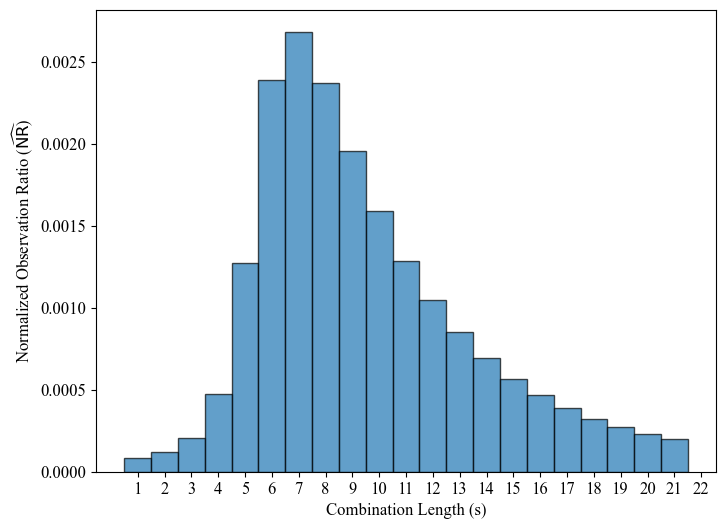

In [8]:

master_top_10=[[0,0] for i in range(20)]
file_name="recorder.txt"
read_list=read_and_process_file(file_name)
normalize_read_list(read_list)
best_res=np.array(read_list)[:,15884]

x=[i for i in range(1,23)]
create_histogram(x,best_res,xlabel="Combination Length (s)",ylabel="Normalized Observation Ratio ($\widehat{\mathrm{NR}}$)")
print()

In [9]:
records = np.array(read_list)
records = np.transpose(records)
print(records.shape)
print(data_df.shape)

(16057, 22)
(16057, 27)


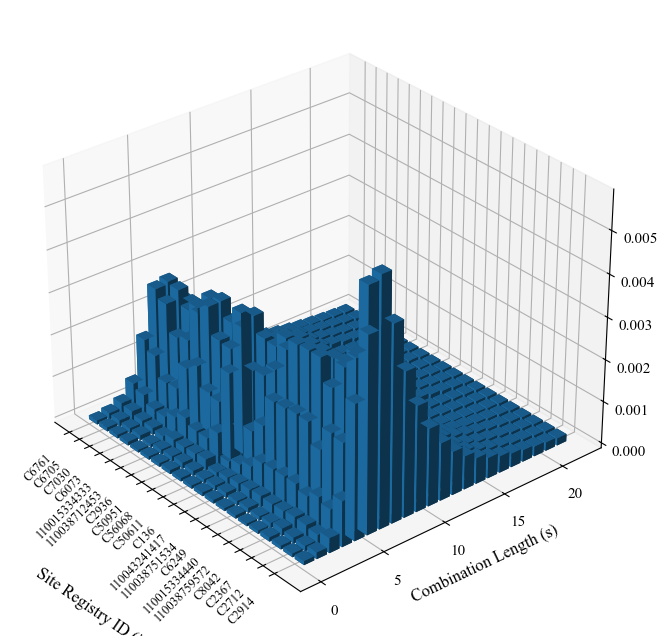

In [ ]:
# Matplotlib font setting
plt.rcParams['font.family'] = ['Times New Roman']

# Assuming `records` is a (16057, 22) numpy array
# Assuming `reg_id_df` is a DataFrame with at least one column for names

# Step 1: Compute row sums
row_sums = np.sum(records, axis=1)

# Step 2: Get indices of top 20 rows
top_20_indices = np.argsort(row_sums)[-20:][::-1]  # Descending order

# Step 3: Retrieve names for these indices
top_20_names = data_df.iloc[top_20_indices, 0].values  # Assuming names are in the first column

# Step 4: Extract top 20 rows while keeping original column order
top_20_data = records[top_20_indices, :]

# Step 5: Reverse the x-axis order
top_20_names = top_20_names[::-1]
top_20_data = top_20_data[::-1, :]  # Reverse row order

# Step 6: Plot 3D histogram with swapped x and y axes
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

xpos, ypos = np.meshgrid(np.arange(20), np.arange(22))  # Swapping axes (rows=20, cols=22)
xpos = xpos.flatten()
ypos = ypos.flatten()

zpos = np.zeros_like(xpos)
values = top_20_data.T.flatten()  # Transpose to match swapped axes

dx = dy = 0.8  # Bar width
dz = values

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)

# Font settings
figfont = {'fontname': 'Times New Roman'}

# Axis labels with requested settings
ax.set_xlabel('Site Registry ID (i)', figfont, fontsize=12, labelpad=40)
ax.set_ylabel('Combination Length (s)', figfont, fontsize=12)
ax.set_zlabel(r'Normalized Observation Ratio ($\widehat{\mathrm{NR}}$)', 
              figfont, fontsize=12, labelpad=10)

# Tick label formatting
plt.xticks(fontname="Times New Roman", fontsize=9)
plt.yticks(fontname="Times New Roman", fontsize=11)
for t in ax.zaxis.get_major_ticks():
    t.label1.set_fontname('Times New Roman')
    t.label1.set_fontsize(11)

# Rotate x-axis tick labels
x_labels = [str(x) for x in top_20_names]
x_list = list(range(20))
plt.xticks(x_list, x_labels, rotation=45, ha='right')

# Adjust view angle
ax.view_init(azim=ax.azim + 20)

# Save figure
plt.savefig("3d_rotated_image.png", dpi=500)

plt.show()

In [12]:
# Load sum_norm_obj_cont.csv and rename its columns
df_obj_cont = pd.read_csv("sum_norm_obj_cont.csv") #, header=None)  There is header in the file
df_obj_cont.columns = [f"obj_cont_{i+1}" for i in range(22)]  # Rename columns to obj_cont_1, ..., obj_cont_22

# Load BF_CPP_DATA.csv
df_bf_cpp = pd.read_csv("BF_CPP_DATA.csv")

# Add obj_cont columns to BF_CPP_DATA.csv, ensuring row order matches
df_bf_cpp = pd.concat([df_bf_cpp, df_obj_cont], axis=1)

# Load loc_id_vs_obs_rate_all.csv
df_all = pd.read_csv("loc_id_vs_obs_rate_all.csv")

# Clean the registryid column in df_all
df_all['registryid'] = df_all['loc_ids'].astype(str).str.strip("[]'")  # Remove brackets and quotes
df_all['siting_metric'] = df_all['obs_values']
df_all.drop(columns=['loc_ids', 'obs_values'], inplace=True)

# Merge df_all with df_bf_cpp using registryid
df_merged = df_bf_cpp.merge(df_all, on="registryid", how="left")

# Save the final dataset
df_merged.to_csv("BF_CPP_XY_Data.csv", index=False)

print("File 'BF_CPP_XY_Data.csv' has been created successfully.")

File 'BF_CPP_XY_Data.csv' has been created successfully.


In [13]:


# Load the CSV files
df1 = df_all.iloc[:20,:]  # Top 20 entries
df2 = pd.read_csv("BF_CPP_DATA.csv")  # Full dataset

# Clean the registryid column in df1 by removing brackets and converting to integers
df1['registryid'] = df1['registryid'].astype(str).str.strip("\'[]").astype(str)

# Merge df1 with df2 to get x and y based on registryid
df_merged = df1.merge(df2[['registryid', 'x', 'y']], on='registryid', how='left')

# Save the result to a new CSV file
df_merged.to_csv("top_20_ready_to_map.csv", index=False)

print("File 'top_20_ready_to_map.csv' has been created successfully.")


File 'top_20_ready_to_map.csv' has been created successfully.


/tmp/ipykernel_208537/1743406395.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['registryid'] = df1['registryid'].astype(str).str.strip("\'[]").astype(str)


[1.0327037256871346e-10, 4.2642802436640476e-10, 1.0700788853627464e-09, 2.7084118039929604e-09, 1.0964738192469412e-08, 3.6164107246694345e-08, 4.9955617800387995e-08, 4.490943572725646e-08, 3.644477804198636e-08, 2.936118389181852e-08, 2.3986516090149723e-08, 1.9927962080939176e-08, 1.6814427218725594e-08, 1.4382219739924208e-08, 1.2454155626695339e-08, 1.091162414274704e-08, 9.67435753021046e-09, 8.687966372257274e-09, 7.917468193332398e-09, 7.345469976301032e-09, 6.9747212657963605e-09, 6.836873468115943e-09]


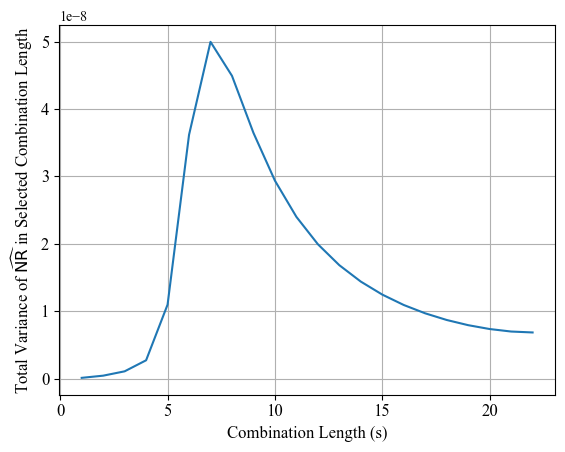

In [14]:


def read_and_process_file(file_path):
    result_list = []

    try:
        with open(file_path, 'r') as file:
            lines = file.readlines()

            # Extract every second line
            for i in range(1, len(lines), 2):
                line = lines[i].strip()

                # Split the line into a list of integers
                integer_series = list(map(int, line.split()))

                result_list.append(integer_series)

        return result_list

    except FileNotFoundError:
        print("File not found. Please check the file path.")
        return None
    except Exception as e:
        print("An error occurred:", e)
        return None
    
def normalize_read_list(lst):
    for i, line in enumerate(lst):
        line_sum = sum(line)
        if line_sum != 0:  # Avoid division by zero
            lst[i] = [element / line_sum for element in line]

def variance_from_mean(arr):
    # Calculate the variance for each row
    return np.var(arr, axis=1).tolist()

file_name = "recorder.txt"
read_list = read_and_process_file(file_name)

if read_list is not None:
    normalize_read_list(read_list)
    np_read_list = np.array(read_list)

    var_res = variance_from_mean(np_read_list)
    x = [i for i in range(1, len(var_res) + 1)]

    print(var_res)

    fig, ax = plt.subplots()
    ax.plot(x, var_res)
    ax.set_xlabel("Combination Length (s)", fontname='Times New Roman', fontsize=12)
    ax.set_ylabel("Total Variance of $\widehat{\mathrm{NR}}$ in Selected Combination Length", fontname='Times New Roman', fontsize=12)
    # ax.set_title("Variance Analysis", fontname='Times New Roman', fontsize=12)
    
    # Set font for tick labels
    ax.tick_params(axis='both', labelsize=12)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Times New Roman')

    # Set font for the scientific notation offset text
    ax.yaxis.get_offset_text().set_fontname('Times New Roman')

    ax.grid()
    plt.savefig("variance_plot.png", dpi=300)
    plt.show()

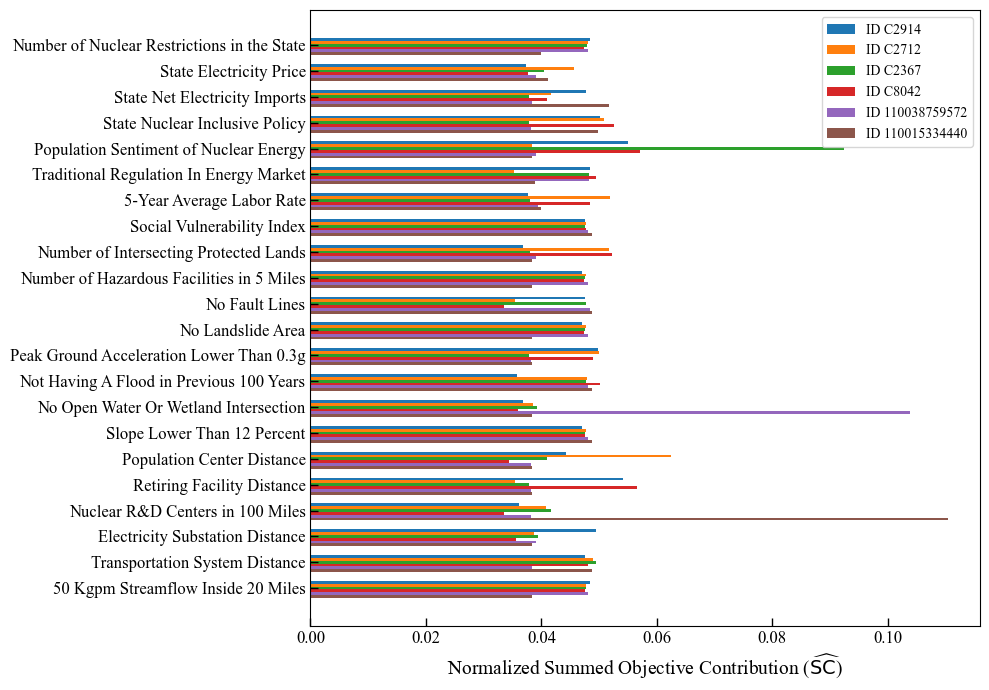

In [15]:


# Characteristics (x-axis labels)
characteristics = [
    'Number of Nuclear Restrictions in the State', 'State Electricity Price', 'State Net Electricity Imports',
    'State Nuclear Inclusive Policy', 'Population Sentiment of Nuclear Energy', 'Traditional Regulation In Energy Market',
    '5-Year Average Labor Rate', 'Social Vulnerability Index', 'Number of Intersecting Protected Lands',
    'Number of Hazardous Facilities in 5 Miles', 'No Fault Lines', 'No Landslide Area',
    'Peak Ground Acceleration Lower Than 0.3g', 'Not Having A Flood in Previous 100 Years',
    'No Open Water Or Wetland Intersection', 'Slope Lower Than 12 Percent', 'Population Center Distance',
    'Retiring Facility Distance', 'Nuclear R&D Centers in 100 Miles', 'Electricity Substation Distance',
    'Transportation System Distance', '50 Kgpm Streamflow Inside 20 Miles'
]

bf_cpp_xy_df = pd.read_csv('BF_CPP_XY_Data.csv')
# Data (5 rows, one for each ID, and 22 columns for each characteristic)

# Sort dataframe by 'siting_metric' in descending order
bf_cpp_xy_df_sorted = bf_cpp_xy_df.sort_values(by='siting_metric', ascending=False)

# Select top 5 rows and objective contribution columns
data = bf_cpp_xy_df_sorted.iloc[:6, 27:49].to_numpy()


# Color mapping for identifiers (IDs)
color_mapping = {
    'C2914': '#1f77b4',        # Blue
    'C2712': '#ff7f0e',        # Orange
    'C2367': '#2ca02c',        # Green
    'C8042': '#d62728',        # Red
    '110038759572': '#9467bd', # Purple
    '110015334440': '#8c564b'  # Brown
}

# Assign each ID to a color
id_colors = list(color_mapping.values())

# Bar positions (based on characteristics)
bar_width = 0.11
index = np.arange(len(characteristics))

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 7))

# Plot bars for each ID
for i, color in enumerate(id_colors):
    ax.barh(index + i * bar_width, data[i], bar_width, label=f"ID {list(color_mapping.keys())[i]}", color=color)

# Customize the chart
ax.set_xlabel('Normalized Summed Objective Contribution ($\widehat{\mathrm{SC}}$)', fontname='Times New Roman', fontsize=14)
ax.set_yticks(index + bar_width * 2)
ax.set_yticklabels(characteristics, fontname='Times New Roman')

# Set x and y ticks font to Times New Roman
ax.tick_params(axis='x', labelsize=12, labelcolor='black', labelrotation=0, width=1, direction='in', length=6)
ax.tick_params(axis='y', labelsize=12, labelcolor='black', labelrotation=0, width=1, direction='in', length=6)
ax.xaxis.set_tick_params(labelsize=12, labelcolor='black', labelrotation=0, width=1)
ax.yaxis.set_tick_params(labelsize=12, labelcolor='black', labelrotation=0, width=1)

plt.legend()
# Invert y-axis to keep the order from top to bottom
ax.invert_yaxis()

# Save the figure with 300 DPI
plt.tight_layout()
plt.savefig("characteristics_bar_chart.png", dpi=300)

# Display the plot
plt.show()


[0.03, 0.17, 0.48, 2.21, 6.61, 21.58, 69.54, 201.45, 458.46, 860.65, 1452.67, 1814.63, 1865.46, 1574.87, 1157.9, 663.16, 314.26, 114.0, 32.72, 6.46, 4.33, 4.26]


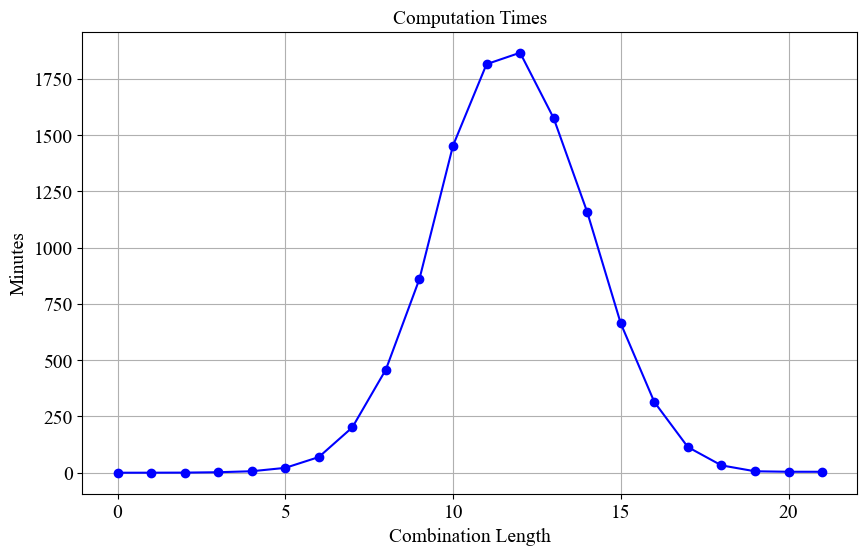

In [16]:
# Read the file
file_path = "recorder.txt"
computation_times = []
with open(file_path, "r") as file:
    for line in file:
        match = re.search(r"Elapsed (\d+\.\d+) mins", line)
        if match:
            computation_times.append(float(match.group(1)))

# Print the extracted times
print(computation_times)

plt.figure(figsize=(10, 6))
plt.plot(computation_times, marker='o', linestyle='-', color='b')
plt.title('Computation Times', fontname='Times New Roman', fontsize=14)
plt.xlabel('Combination Length', fontname='Times New Roman', fontsize=14)
plt.ylabel('Minutes', fontname='Times New Roman', fontsize=14)
plt.xticks(fontname='Times New Roman', fontsize=14)
plt.yticks(fontname='Times New Roman', fontsize=14)
plt.grid(True)
plt.show()

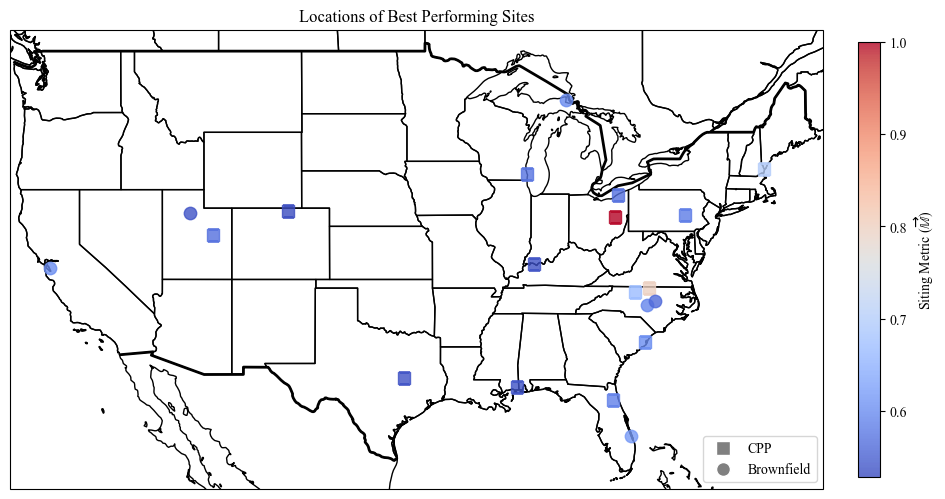

In [18]:


# Reversed Data
data = {
    'Registry ID': [
        'C2914', 'C2712', 'C2367', 'C8042', '110038759572', '110015334440', 'C6249', '110038751534',
        '110043241417', 'C136', 'C50611', 'C56068', 'C50951', 'C2936', '110038712453', '110015334333',
        'C6073', 'C7030', 'C6705', 'C6761'
    ],
    'Longitude': [
        -81.46815, -79.0731, -70.7842, -80.0603, -80.32, -122.1, -79.35724, -85.04,
        -79.19, -81.63278, -76.45, -87.8336, -110.3917, -81.254, -78.63, -112.02,
        -88.5553, -96.69503, -87.3328, -105.0212
    ],
    'Latitude': [
        40.520066, 36.4833, 43.0978, 36.2811, 27.42, 37.67, 33.33184, 46.61,
        35.49, 29.733056, 40.6191, 42.8492, 39.5472, 41.7265, 35.76, 40.72,
        30.5322, 31.091925, 37.915, 40.860905
    ],
    'Siting Metric': [
    1.0, 0.7991088893412379, 0.7024962174015452, 0.6650321979625818, 
    0.6168741631187121, 0.6017711093917133, 0.6005502220042526, 0.597281829696846, 
    0.5927438105487253, 0.5868290491214819, 0.5805731315224438, 0.5726682722680971, 
    0.5678012219828754, 0.5673419754185612, 0.5612345494644894, 0.5364642348422098, 
    0.5363179273550641, 0.5352988654161009, 0.5344111271104323, 0.5285220360412378
    ]
}

# Convert to numpy arrays
longitudes = np.array(data['Longitude'])
latitudes = np.array(data['Latitude'])
siting_metrics = np.array(data['Siting Metric'])
registry_ids = np.array(data['Registry ID'])

# Create color map for siting metric
norm = colors.Normalize(vmin=min(siting_metrics), vmax=max(siting_metrics))
cmap = cm.coolwarm

# Create a map with Mercator projection
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.Mercator())

# Set extent to match your coordinates (llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat)
ax.set_extent([-125, -66.5, 24, 50], crs=ccrs.PlateCarree())

# Add map features
ax.coastlines(resolution='50m', zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=2, zorder=2)  # Country borders
ax.add_feature(cfeature.STATES, linewidth=1, zorder=3)   # US states

# Loop through data and plot points
sc = None
for i in range(len(registry_ids)):
    lon, lat = longitudes[i], latitudes[i]
    if registry_ids[i].startswith('C'):
        marker = 's'
    else:
        marker = 'o'
    
    sc = ax.scatter(
        lon, lat,
        c=[siting_metrics[i]],  # Single-value color
        cmap=cmap,
        norm=norm,
        s=80,
        marker=marker,
        zorder=4,
        alpha=0.8,
        transform=ccrs.PlateCarree()
    )

# Add a colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.025, pad=0.04)
cbar.set_label('Siting Metric ($\\overrightarrow{\\mathbb{M}}$)')

# Custom legend
legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='CPP'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Brownfield')
]
plt.legend(handles=legend_elements, loc='lower right')

# Title and layout
plt.title("Locations of Best Performing Sites")
plt.subplots_adjust(right=0.85)

# Save and show
plt.savefig('us_map_with_siting_metrics_cartopy.png', dpi=300, bbox_inches='tight')
plt.show()
